In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri May 27 2022

@author: Anahí Romo
"""
#!pip3 install pydot-ng
#%%
import pandas as pd
import numpy as np
import pyAgrum as gum
import pyAgrum.lib.notebook as gnb

In [ ]:
#  OJO!!! ESTO OCUPA MUCHÍSIMA MEMORIA, ES PROBABLE QUE NO SE PUEDA CARGAR
# eso me pasó a mí. Entonces en el sgte bloque vemos cómo superar este problema


#######       OPCIÓN 1 SI TENEMOS MUCHA MEMORIA RAM (MÁS DE 16G AL MENOS)
# =============================================================================
#
# df_BIG = pd.read_csv('220430COVID19MEXICO.csv',
#                  usecols = ['FECHA_DEF', 'ASMA', 'HIPERTENSION',
#                             'TABAQUISMO', 'CLASIFICACION_FINAL'],
#                  low_memory = False)
#
# print(df_BIG.shape)
# print(df_BIG.columns)
# print(df_BIG.describe().T)
#
# =============================================================================
#%%           OPCIÓN 2 PARA NO CARGAR TODO EN LA RAM: CORTAMOS EL CSV ENORME
#    EN PEDAZOS MÁS CHICOS Y LOS PROCESAMOS POR SEPARADO


###########################################################################
# NECESITAMOS CONTAR LOS CASOS Q NOS INTERESAN PARA CALCULAR LAS PROBABILIDADES
# PARA ELLO, CARGO LOS ARCHVOS CHICOS EN UN DATAFRAME CON LAS COLUMNAS Q SIRVEN

# POR EJEMPLO:
# 01 cargar datos

df = pd.read_csv('file_1.csv',
                 usecols = ['FECHA_DEF', 'ASMA', 'HIPERTENSION',
                            'TABAQUISMO', 'CLASIFICACION_FINAL'])
#                  low_memory = False)

print('Shape', df.shape)       # (988003, 5)
print('Columns', df.columns) # ['FECHA_DEF', 'ASMA', 'HIPERTENSION', 'TABAQUISMO','CLASIFICACION_FINAL']
print(df.describe().T)
print(df.head())
print('Hay valores ausentes?', df.isnull().values.any())     #  False -» no hay valores ausentes


Shape (988003, 5)
Columns Index(['FECHA_DEF', 'ASMA', 'HIPERTENSION', 'TABAQUISMO',
       'CLASIFICACION_FINAL'],
      dtype='object')
                        count      mean       std  min  25%  50%  75%   max
ASMA                 988003.0  2.257230  5.256557  1.0  2.0  2.0  2.0  98.0
HIPERTENSION         988003.0  2.140621  5.386990  1.0  2.0  2.0  2.0  98.0
TABAQUISMO           988003.0  2.229687  5.459159  1.0  2.0  2.0  2.0  98.0
CLASIFICACION_FINAL  988003.0  5.185756  1.900562  1.0  3.0  6.0  7.0   7.0
    FECHA_DEF  ASMA  HIPERTENSION  TABAQUISMO  CLASIFICACION_FINAL
0  9999-99-99     2             2           2                    6
1  9999-99-99     1             2           2                    7
2  9999-99-99     2             2           2                    3
3  9999-99-99     2             2           2                    7
4  9999-99-99     2             1           2                    7
Hay valores ausentes? False


In [ ]:
#%%    02 depurando el dataframe
# ME QUEDO CON LOS CASOS CONFIRMADOS COVID POSITIVO O NEGATIVO
# de la columna 'CLASIFICACION_FINAL' eliminamos los que tengan valor 4, 5 o 6

i4 = df[df['CLASIFICACION_FINAL'] == 4].index     # seleccionamos
i5 = df[df['CLASIFICACION_FINAL'] == 5].index
i6 = df[df['CLASIFICACION_FINAL'] == 6].index
df.drop(i4, inplace = True)                      #  borramos
df.drop(i5, inplace = True)
df.drop(i6, inplace = True)

print('Shape después de depurar', df.shape)     # (839881, 5)
print(df.head())

Shape después de depurar (839881, 5)
    FECHA_DEF  ASMA  HIPERTENSION  TABAQUISMO  CLASIFICACION_FINAL
1  9999-99-99     1             2           2                    7
2  9999-99-99     2             2           2                    3
3  9999-99-99     2             2           2                    7
4  9999-99-99     2             1           2                    7
5  9999-99-99     2             2           2                    7


In [ ]:
#%% 03 valores

print('CLASIFICACION_FINAL', df['CLASIFICACION_FINAL'].unique())
print('Fallecidos', df['FECHA_DEF'].unique().size)
print('Asma', df['ASMA'].unique())
print('Tabaquismo', df['TABAQUISMO'].unique())
print('Hipertensión', df['HIPERTENSION'].unique())

CLASIFICACION_FINAL [7 3 1 2]
Fallecidos 358
Asma [ 1  2 98]
Tabaquismo [ 2  1 98]
Hipertensión [ 2  1 98]


In [ ]:
# aparecen 98 -> se ignora, vamos a eliminarlos
sacar1 = df[df['TABAQUISMO'] == 98].index
df.drop(sacar1, inplace=True)
#%%
sacar2 = df[df['ASMA'] == 98].index
df.drop(sacar2, inplace=True)
#%%
sacar3 = df[df['HIPERTENSION'] == 98].index
df.drop(sacar3, inplace=True)
df

,FECHA_DEF,ASMA,HIPERTENSION,TABAQUISMO,CLASIFICACION_FINAL
1,9999-99-99,1,2,2,7
2,9999-99-99,2,2,2,3
3,9999-99-99,2,2,2,7
4,9999-99-99,2,1,2,7
5,9999-99-99,2,2,2,7
...,...,...,...,...,...
987997,9999-99-99,2,2,2,7
987998,9999-99-99,2,1,2,7
987999,9999-99-99,2,2,2,7
988000,9999-99-99,2,2,2,3


In [ ]:
print('Asma', df['ASMA'].unique())
print('Tabaquismo', df['TABAQUISMO'].unique())
print('Hipertensión', df['HIPERTENSION'].unique())


Asma [1 2]
Tabaquismo [2 1]
Hipertensión [2 1]


In [ ]:
#%%    04   creamos un identificador para Covid positivo / negativo: 1, 2, 3=true, 7=false
#  cambiamos los cod 97/98/99 por 0 en todo el dataframe
#  las fechas '9999-99-99' en 'FECHA_DEF' son pacientes vivos  -» ponemos False
# las demás fechas ponemos True  -» pacientes fallecidos

df['COVID'] = df['CLASIFICACION_FINAL'].map({ 1:1,2:1, 3:1, 7:0})

df.head()

,FECHA_DEF,ASMA,HIPERTENSION,TABAQUISMO,CLASIFICACION_FINAL,COVID
1,9999-99-99,1,2,2,7,0
2,9999-99-99,2,2,2,3,1
3,9999-99-99,2,2,2,7,0
4,9999-99-99,2,1,2,7,0
5,9999-99-99,2,2,2,7,0


In [ ]:
#%%  05
print('COVID', df['COVID'].unique())

COVID [0 1]


In [ ]:
#%%  07
df.loc[df.FECHA_DEF != '9999-99-99', 'FECHA_DEF'] = 1
df.loc[df.FECHA_DEF == '9999-99-99', 'FECHA_DEF'] = 0
print(df.head())

  FECHA_DEF  ASMA  HIPERTENSION  TABAQUISMO  CLASIFICACION_FINAL  COVID
1         0     1             2           2                    7      0
2         0     2             2           2                    3      1
3         0     2             2           2                    7      0
4         0     2             1           2                    7      0
5         0     2             2           2                    7      0


In [ ]:
#%%  08 eliminar Clasif...
del df['CLASIFICACION_FINAL']
df

,FECHA_DEF,ASMA,HIPERTENSION,TABAQUISMO,COVID
1,0,1,2,2,0
2,0,2,2,2,1
3,0,2,2,2,0
4,0,2,1,2,0
5,0,2,2,2,0
...,...,...,...,...,...
987997,0,2,2,2,0
987998,0,2,1,2,0
987999,0,2,2,2,0
988000,0,2,2,2,1


In [ ]:
#%%. 09 en la codificación del csv, 1 es Sí y 2 es NO. Lo cambiamos a 0 es NO
df = df.replace(to_replace=2, value=0)
print(df.head())

   FECHA_DEF  ASMA  HIPERTENSION  TABAQUISMO  COVID
1          0     1             0           0      0
2          0     0             0           0      1
3          0     0             0           0      0
4          0     0             1           0      0
5          0     0             0           0      0


In [ ]:
#%%  10. renombrar columna
df.rename(columns={'FECHA_DEF': 'DEF'}, inplace=True)
df


,DEF,ASMA,HIPERTENSION,TABAQUISMO,COVID
1,0,1,0,0,0
2,0,0,0,0,1
3,0,0,0,0,0
4,0,0,1,0,0
5,0,0,0,0,0
...,...,...,...,...,...
987997,0,0,0,0,0
987998,0,0,1,0,0
987999,0,0,0,0,0
988000,0,0,0,0,1


In [ ]:
#%% a ver que valores tiene cada columna

print('COVID', df['COVID'].unique())
print('Fallecidos', df['DEF'].unique())
print('Asma', df['ASMA'].unique())
print('Tabaquismo', df['TABAQUISMO'].unique())
print('Hipertensión', df['HIPERTENSION'].unique())

COVID [0 1]
Fallecidos [0 1]
Asma [1 0]
Tabaquismo [0 1]
Hipertensión [0 1]


In [ ]:
#%%     11. creamos la red

red = gum.BayesNet('covid')                                      # creamos red
print(red)


BN{nodes: 0, arcs: 0, domainSize: 1, dim: 0, mem: 0o}


In [ ]:
#%%    12. agregamos las variables

a = red.add(gum.LabelizedVariable('ASMA','a',2))        #agregamos 1ra var
print(a)
t = red.add(gum.LabelizedVariable('TABAQUISMO','t', 2))  #agregamos 2° var
print(t)
h = red.add(gum.LabelizedVariable('HIPERTENSION', 'h', 2))  # 3ra variable
print(h)
c = red.add(gum.LabelizedVariable('COVID', 'c', 2))       # 4ta variable
print(c)
m = red.add(gum.LabelizedVariable('DEF','m', 2))          # 5ta variable
print(m)


0
1
2
3
4


In [ ]:
#%%   veamos la red

print(red)

BN{nodes: 5, arcs: 0, domainSize: 32, dim: 5, mem: 80o}


In [ ]:
#%%   13. arcos

red.addArc(a, c)                                     # agregamos los arcos
red.addArc(a, m)
red.addArc(t, c)
red.addArc(t, m)
red.addArc(h, c)
red.addArc(h, m)
red.addArc(c, m)


In [ ]:

red

(pyAgrum.BayesNet@0x7f7788a91a00) BN{nodes: 5, arcs: 7, domainSize: 32, dim: 27, mem: 432o}

📌 Relaciones representadas

HIPERTENSIÓN → COVID

La hipertensión influye en la probabilidad de contraer o sufrir complicaciones por COVID.

TABAQUISMO → COVID

El tabaquismo también aumenta el riesgo de COVID.

ASMA → COVID

El asma incrementa la vulnerabilidad al COVID.

HIPERTENSIÓN, TABAQUISMO, ASMA → DEF

Estas condiciones pueden influir directamente en la probabilidad de defunción, independientemente de COVID.

COVID → DEF

Tener COVID es un factor central que aumenta la probabilidad de defunción.

🔮 Interpretación

Este grafo describe cómo los factores de riesgo (hipertensión, tabaquismo, asma) afectan:

La probabilidad de contraer COVID.

La probabilidad de fallecer (DEF), ya sea directamente o indirectamente a través del COVID.

In [ ]:
#%%  14. ahora a cargar las tablas de probabilidades condicionales o CPT


def computeCPTfromDF(bn,df,name):
    """
    Compute the CPT of variable "name" in the BN bn from the database df
    """
    id=bn.idFromName(name)
    parents=list(reversed(bn.cpt(id).names))
    domains=[bn[name].domainSize()
             for name in parents]
    parents.pop()

    if (len(parents)>0):
        c=pd.crosstab(df[name],[df[parent] for parent in parents])
        s=c/c.sum().apply(np.float32)
    else:
        s=df[name].value_counts(normalize=True)

    bn.cpt(id)[:]=np.array((s).transpose()).reshape(*domains)

def ParametersLearning(bn,df):
    """
    Compute the CPTs of every varaible in the BN bn from the database df
    """
    for name in bn.names():
        computeCPTfromDF(bn,df,name)

ParametersLearning(red,df)
red

In [22]:
red.cpt('COVID')

(pyAgrum.Potential@0x7f7728241970) 
                    ||  COVID            |
ASMA  |TABAQU|HIPERT||0        |1        |
------|------|------||---------|---------|
0     |0     |0     || 0.5406  | 0.4594  |
1     |0     |0     || 0.6079  | 0.3921  |
0     |1     |0     || 0.5938  | 0.4062  |
1     |1     |0     || 0.6621  | 0.3379  |
0     |0     |1     || 0.4143  | 0.5857  |
1     |0     |1     || 0.4912  | 0.5088  |
0     |1     |1     || 0.4944  | 0.5056  |
1     |1     |1     || 0.5828  | 0.4172  |

In [23]:
red.cpt('DEF')

(pyAgrum.Potential@0x7f77290df030) 
                           ||  DEF              |
ASMA  |TABAQU|HIPERT|COVID ||0        |1        |
------|------|------|------||---------|---------|
0     |0     |0     |0     || 0.9787  | 0.0213  |
1     |0     |0     |0     || 0.9885  | 0.0115  |
0     |1     |0     |0     || 0.9746  | 0.0254  |
1     |1     |0     |0     || 0.9829  | 0.0171  |
0     |0     |1     |0     || 0.9007  | 0.0993  |
1     |0     |1     |0     || 0.9450  | 0.0550  |
[...4 more line(s) ...]
0     |1     |0     |1     || 0.8850  | 0.1150  |
1     |1     |0     |1     || 0.9164  | 0.0836  |
0     |0     |1     |1     || 0.6780  | 0.3220  |
1     |0     |1     |1     || 0.7662  | 0.2338  |
0     |1     |1     |1     || 0.6427  | 0.3573  |
1     |1     |1     |1     || 0.7851  | 0.2149  |

In [24]:
red.cpt('ASMA')

(pyAgrum.Potential@0x7f7729122730) 
  ASMA             |
0        |1        |
---------|---------|
 0.9691  | 0.0309  |

In [25]:
red.cpt('HIPERTENSION')

(pyAgrum.Potential@0x7f77282a29a0) 
  HIPERTENSION     |
0        |1        |
---------|---------|
 0.8350  | 0.1650  |

In [26]:
red.cpt('TABAQUISMO')

(pyAgrum.Potential@0x7f77282ae550) 
  TABAQUISMO       |
0        |1        |
---------|---------|
 0.9177  | 0.0823  |

In [27]:
# 15. propagar información
ie = gum.LazyPropagation(red)

In [28]:
ie.makeInference()

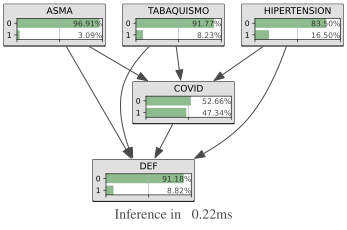

In [29]:
gnb.showInference(red,evs={})

In [30]:
#%%  agregamos evidencia y preguntamos
# la evidencia es 'cov' = 1, le preguntamos cuál es la probabilidad de 'muerte'

ie.setEvidence({'COVID':1})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))

(pyAgrum.Potential@0x7f77affde0f0) 
  DEF              |
0        |1        |
---------|---------|
 0.8490  | 0.1510  |

In [31]:
#%%  agregamos evidencia y preguntamos
# la evidencia es 'cov' = 0, le preguntamos cuál es la probabilidad de 'muerte'

ie.setEvidence({'COVID':0})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))

(pyAgrum.Potential@0x7f772926f090) 
  DEF              |
0        |1        |
---------|---------|
 0.9682  | 0.0318  |

In [32]:
#%% agregamos más evidencia y preguntamos desde otra variable
# la evidencia es 'COVID' = 1 y 'ASMA' = 1, la pregunta es la prob de 'DEF'

ie.setEvidence({'COVID':1, 'ASMA':1})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))

(pyAgrum.Potential@0x7f77290808d0) 
  DEF              |
0        |1        |
---------|---------|
 0.8940  | 0.1060  |

In [33]:
#%%
#la evidencia es 'COVID' = 0 y 'ASMA' = 1, la pregunta es la prob de 'DEF'

ie.setEvidence({'COVID':0, 'ASMA':1})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))#

(pyAgrum.Potential@0x7f772926f070) 
  DEF              |
0        |1        |
---------|---------|
 0.9819  | 0.0181  |

In [34]:
#%%  idem para 'ht' = 1 ...

ie.setEvidence({'COVID':1, 'HIPERTENSION':1})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))

(pyAgrum.Potential@0x7f7728697cf0) 
  DEF              |
0        |1        |
---------|---------|
 0.6779  | 0.3221  |

In [36]:
#%%  idem para 'ht' = 1 ...

ie.setEvidence({'COVID':0, 'HIPERTENSION':1})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))

(pyAgrum.Potential@0x7f77292413a0) 
  DEF              |
0        |1        |
---------|---------|
 0.9000  | 0.1000  |

In [37]:
#%%     ...y 'tab'= 1

ie.setEvidence({'COVID':1, 'TABAQUISMO':1})
ie.makeInference()
ie.posterior(m)
#print(ie.posterior(m))

(pyAgrum.Potential@0x7f77b08098d0) 
  DEF              |
0        |1        |
---------|---------|
 0.8385  | 0.1615  |

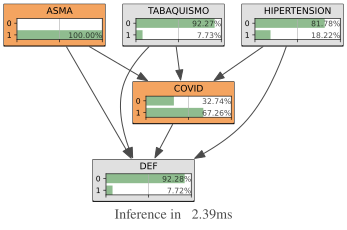

In [38]:
#  con lo anterior, ya podemos responder las preguntas planteadas

# también se puede agregar evidencia 'soft'. En este caso, para Covid...

gnb.showInference(red,evs={'COVID':[0.3, 0.9], 'ASMA':1})